# Comparación de la distribución de salario anual en roles de datos usando un Boxplot

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast 
import locale

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_d = df.dropna(subset=['salary_year_avg'])

df_d

In [ ]:
job_titles = df_d['job_title_short'].value_counts().index[:6].to_list()

job_titles

In [ ]:
df_top6 = df_d[df_d['job_title_short'].isin(job_titles)]

df_top6

In [16]:
job_order = df_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

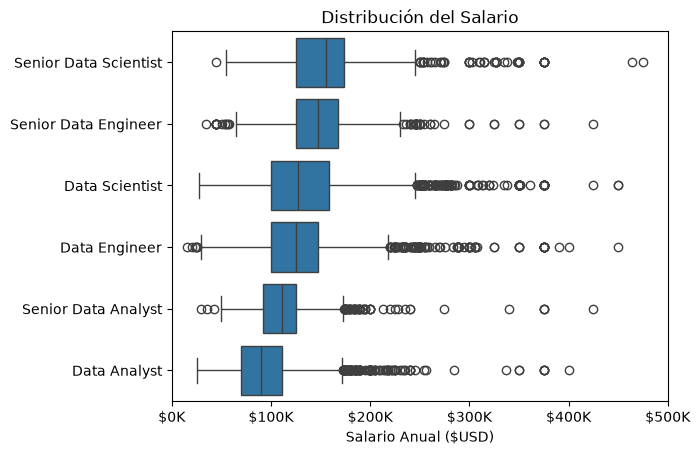

In [21]:
sns.boxplot(data=df_top6, x='salary_year_avg', y='job_title_short', order=job_order)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.title('Distribución del Salario')
plt.xlabel('Salario Anual ($USD)')
plt.xlim(0, 500_000)
plt.ylabel('')
plt.show()